In [1]:
import sys
sys.path.insert(0, '../src')

from utils.config import *
from utils.data import *
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

all_data = load_folder('../data/train') + load_folder('../data/test')

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


12:02:03 | INFO | Encontrados 64 arquivos PLY em ../data/train
12:02:03 - INFO: Encontrados 64 arquivos PLY em ../data/train
12:02:04 | INFO |   OK avaria_10.ply | 7,971 pts | crack=True
12:02:04 - INFO:   OK avaria_10.ply | 7,971 pts | crack=True
12:02:05 | INFO |   OK avaria_12.ply | 7,636 pts | crack=True
12:02:05 - INFO:   OK avaria_12.ply | 7,636 pts | crack=True
12:02:07 | INFO |   OK avaria_13.ply | 11,880 pts | crack=True
12:02:07 - INFO:   OK avaria_13.ply | 11,880 pts | crack=True
12:02:11 | INFO |   OK avaria_17.ply | 24,367 pts | crack=True
12:02:11 - INFO:   OK avaria_17.ply | 24,367 pts | crack=True
12:02:14 | INFO |   OK avaria_19.ply | 22,914 pts | crack=True
12:02:14 - INFO:   OK avaria_19.ply | 22,914 pts | crack=True
12:02:18 | INFO |   OK avaria_2.ply | 23,988 pts | crack=True
12:02:18 - INFO:   OK avaria_2.ply | 23,988 pts | crack=True
12:02:20 | INFO |   OK avaria_20.ply | 15,509 pts | crack=True
12:02:20 - INFO:   OK avaria_20.ply | 15,509 pts | crack=True
12:02:

In [2]:
print(f"{'Arquivo':<35} {'classe':<8} {'min':>6} {'max':>6} {'mean':>6} {'n':>7}")
print("-" * 75)

for d in sorted(all_data, key=lambda x: x['filename']):
  sf     = d['features'][:, 9]
  labels = d['labels']

  for cls, name in [(1, 'crack'), (0, 'normal')]:
      mask = labels == cls
      if mask.sum() == 0:
          continue
      s = sf[mask]
      print(f"{d['filename']:<35} {name:<8} "
            f"{s.min():>6.3f} {s.max():>6.3f} {s.mean():>6.3f} {mask.sum():>7,}")
  print()

Arquivo                             classe      min    max   mean       n
---------------------------------------------------------------------------
Interno_esquerda_corredor_parede_fundo.ply normal    0.000  1.000  0.418  26,314

Interno_esquerda_pilastra1.ply      normal    0.000  1.000  0.362   4,315

Interno_esquerda_pilastra2.ply      normal    0.000  1.000  0.362   7,054

Interno_esquerda_pilastra3.ply      normal    0.000  1.000  0.390   8,825

Interno_esquerda_pilastra4.ply      normal    0.000  1.000  0.502   3,025

avaria_10.ply                       crack     0.000  0.260  0.178   1,056
avaria_10.ply                       normal    0.269  1.000  0.437   6,915

avaria_12.ply                       crack     0.110  0.440  0.249     440
avaria_12.ply                       normal    0.000  1.000  0.850   7,196

avaria_13.ply                       crack     0.134  0.356  0.258     794
avaria_13.ply                       normal    0.000  1.000  0.559  11,086

avaria_17.ply        

In [10]:
import os
os.makedirs('../visualizations_sf', exist_ok=True)

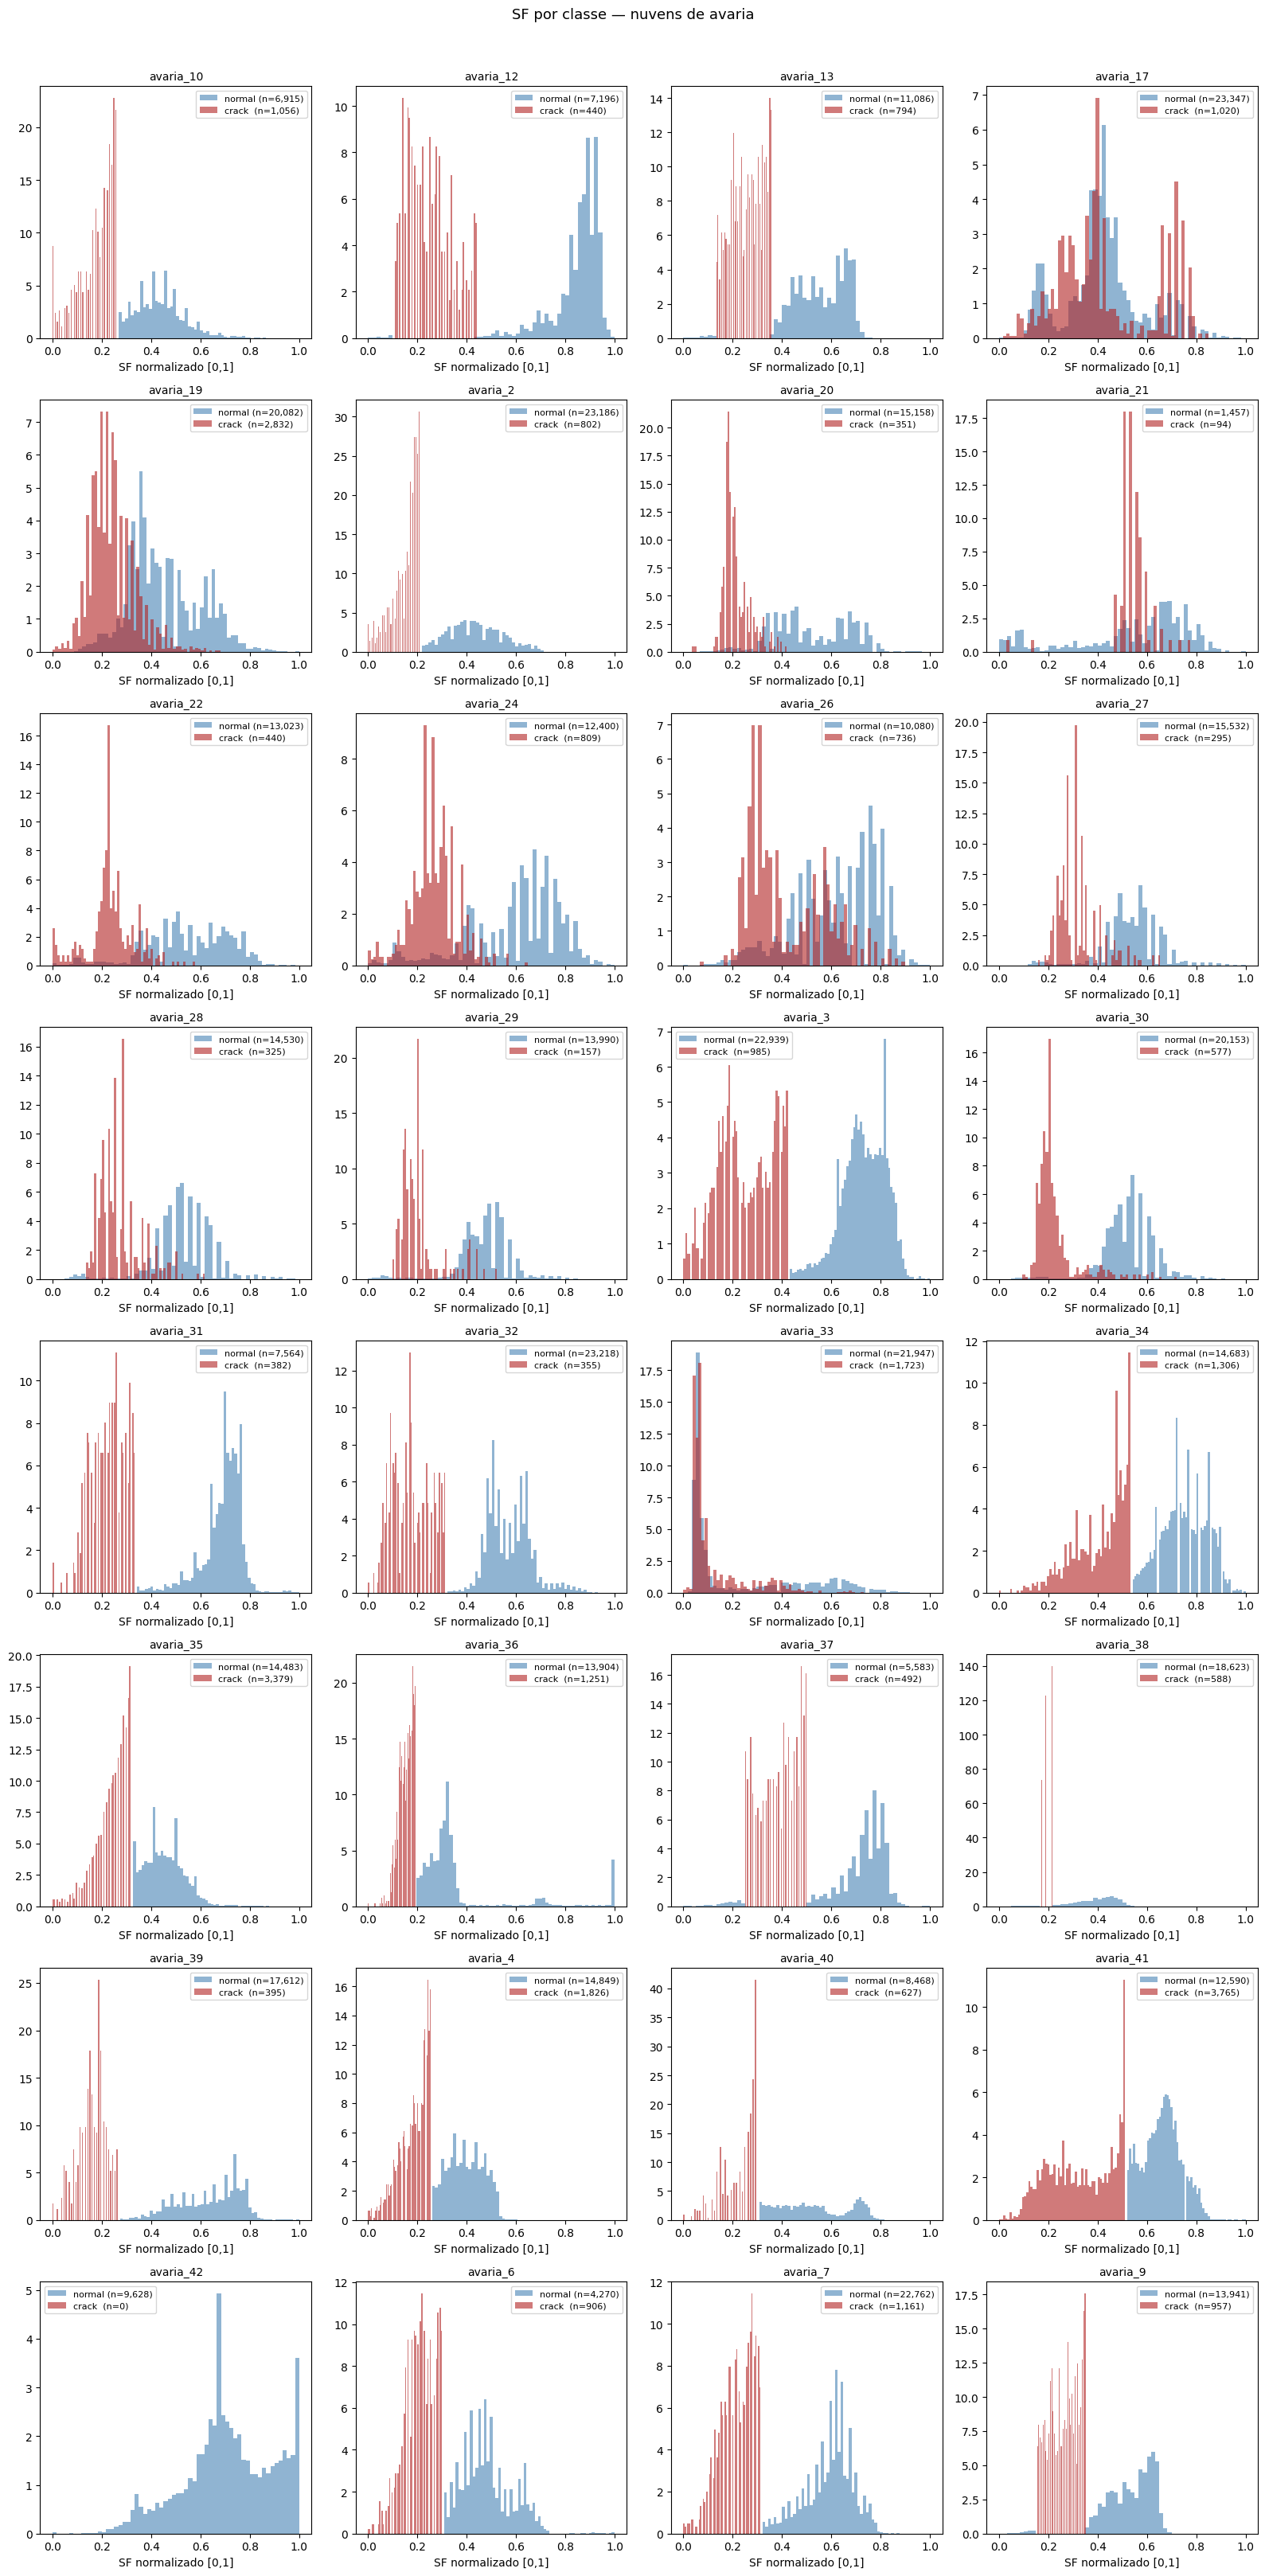

In [3]:
crack_clouds = [d for d in all_data if d['has_crack']]
n = len(crack_clouds)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = axes.flatten()

for ax, d in zip(axes, sorted(crack_clouds, key=lambda x: x['filename'])):
  sf     = d['features'][:, 9]
  labels = d['labels']
  crack_sf  = sf[labels == 1]
  normal_sf = sf[labels == 0]

  ax.hist(normal_sf, bins=60, alpha=0.6, label=f'normal (n={len(normal_sf):,})',
          color='steelblue', density=True)
  ax.hist(crack_sf,  bins=60, alpha=0.6, label=f'crack  (n={len(crack_sf):,})',
          color='firebrick', density=True)
  ax.set_title(d['filename'].replace('.ply', ''), fontsize=10)
  ax.set_xlabel('SF normalizado [0,1]')
  ax.legend(fontsize=8)

# Esconde eixos vazios
for ax in axes[n:]:
  ax.set_visible(False)

plt.suptitle('SF por classe — nuvens de avaria', fontsize=13, y=1.01)
plt.tight_layout()
os.makedirs('../visualizations_sf', exist_ok=True)
plt.savefig('../visualizations_sf/sf_dist_grid.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:

# ── Imports extras para esta análise ─────────────────────────────────────────
from sklearn.metrics import roc_auc_score
from utils.evaluation import ScalarFieldGMM

def extract_gmm_interval(d: dict) -> dict:
    """
    Ajusta ScalarFieldGMM na nuvem e extrai parâmetros do componente crack.

    Retorna dict com:
      mu_crack      — centro do componente crack no SF normalizado
      sigma_crack   — spread do componente crack
      crack_weight  — fração do GMM atribuída ao crack
      interval_lo/hi— [mu - 2σ, mu + 2σ]
      overlap_ratio — fração dos pontos NORMAIS dentro do intervalo de crack
                      > 0.40 → nuvem irrecuperável por SF sozinho
      is_bimodal    — GMM encontrou dois clusters distintos
      auroc_sf      — AUROC do SF puro (teto esperado para esta nuvem)
    """
    sf     = d['features'][:, 9].astype(float)
    labels = d['labels']

    gmm = ScalarFieldGMM(sf).fit()

    auroc_sf = float('nan')
    if labels is not None and labels.sum() >= 5:
        try:
            auroc_sf = roc_auc_score(labels, -sf)
        except Exception:
            pass

    if gmm.modality == 'unimodal' or gmm._gmm is None:
        return dict(
            filename=d['filename'], is_bimodal=False,
            mu_crack=float('nan'), sigma_crack=float('nan'),
            crack_weight=float('nan'), interval_lo=float('nan'),
            interval_hi=float('nan'), overlap_ratio=float('nan'),
            auroc_sf=auroc_sf,
            n_crack=int(labels.sum()) if labels is not None else 0,
            n_normal=int((labels == 0).sum()) if labels is not None else len(sf),
        )

    g  = gmm._gmm
    ci = gmm._crack_idx
    mu    = float(g.means_[ci, 0])
    sigma = float(np.sqrt(g.covariances_[ci, 0, 0])) + 1e-8
    wt    = float(g.weights_[ci])
    lo, hi = mu - 2 * sigma, mu + 2 * sigma

    thr = gmm.threshold
    normal_mask = sf > thr if mu <= thr else sf < thr
    overlap = float(((sf[normal_mask] >= lo) & (sf[normal_mask] <= hi)).mean()) if normal_mask.sum() > 0 else 0.0

    return dict(
        filename=d['filename'], is_bimodal=True,
        mu_crack=round(mu, 4), sigma_crack=round(sigma, 4),
        crack_weight=round(wt, 4), interval_lo=round(lo, 4),
        interval_hi=round(hi, 4), overlap_ratio=round(overlap, 4),
        auroc_sf=round(float(auroc_sf), 4) if not np.isnan(auroc_sf) else float('nan'),
        n_crack=int(labels.sum()) if labels is not None else 0,
        n_normal=int((labels == 0).sum()) if labels is not None else len(sf),
    )

print("extract_gmm_interval definido.")


extract_gmm_interval definido.


In [5]:

# ── Roda extract_gmm_interval em todas as nuvens avaria ──────────────────────
import pandas as pd

crack_clouds = [d for d in all_data if d['has_crack']]
rows = [extract_gmm_interval(d) for d in sorted(crack_clouds, key=lambda x: x['filename'])]
df = pd.DataFrame(rows)

# Ordena por overlap_ratio (clouds mais difíceis primeiro)
df_sorted = df.sort_values('overlap_ratio', ascending=False)

# ── Tabela formatada ──────────────────────────────────────────────────────────
print(f"{'Arquivo':<35} {'bimodal':<8} {'mu_crack':>9} {'sigma':>7} {'wt':>6} "
      f"{'lo':>7} {'hi':>7} {'overlap':>8} {'auroc_sf':>9} {'n_crack':>8}")
print("─" * 110)

for _, r in df_sorted.iterrows():
    bi   = 'SIM' if r['is_bimodal'] else 'NÃO'
    flag = ' ⚠' if (not np.isnan(r['overlap_ratio']) and r['overlap_ratio'] > 0.40) else ''
    print(
        f"{r['filename']:<35} {bi:<8} "
        f"{r['mu_crack']:>9.4f} {r['sigma_crack']:>7.4f} {r['crack_weight']:>6.4f} "
        f"{r['interval_lo']:>7.4f} {r['interval_hi']:>7.4f} "
        f"{r['overlap_ratio']:>8.4f} {r['auroc_sf']:>9.4f} {r['n_crack']:>8,}{flag}"
    )

n_unimodal = df['is_bimodal'].eq(False).sum()
n_high_overlap = (df['overlap_ratio'] > 0.40).sum()
print(f"\nTotal: {len(df)} nuvens | Unimodais: {n_unimodal} | overlap>0.40 (irrecuperáveis): {n_high_overlap}")
print(f"AUROC SF puro — média: {df['auroc_sf'].mean():.4f}  std: {df['auroc_sf'].std():.4f}  min: {df['auroc_sf'].min():.4f}")


Arquivo                             bimodal   mu_crack   sigma     wt      lo      hi  overlap  auroc_sf  n_crack
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
avaria_35.ply                       SIM         0.2848  0.0940 0.2409  0.0967  0.4729   0.6275    1.0000    3,379 ⚠
avaria_34.ply                       SIM         0.4812  0.1413 0.1176  0.1986  0.7639   0.5919    1.0000    1,306 ⚠
avaria_4.ply                        SIM         0.2296  0.0898 0.1532  0.0500  0.4093   0.5716    1.0000    1,826 ⚠
avaria_38.ply                       SIM         0.2331  0.0978 0.1414  0.0375  0.4288   0.5575    0.9681      588 ⚠
avaria_3.ply                        SIM         0.3933  0.1769 0.0814  0.0394  0.7471   0.5329    1.0000      985 ⚠
avaria_9.ply                        SIM         0.2897  0.1251 0.0993  0.0396  0.5399   0.4632    0.9860      957 ⚠
avaria_32.ply                       SIM         0.2639  0.1367 0.0239 -0.0096  

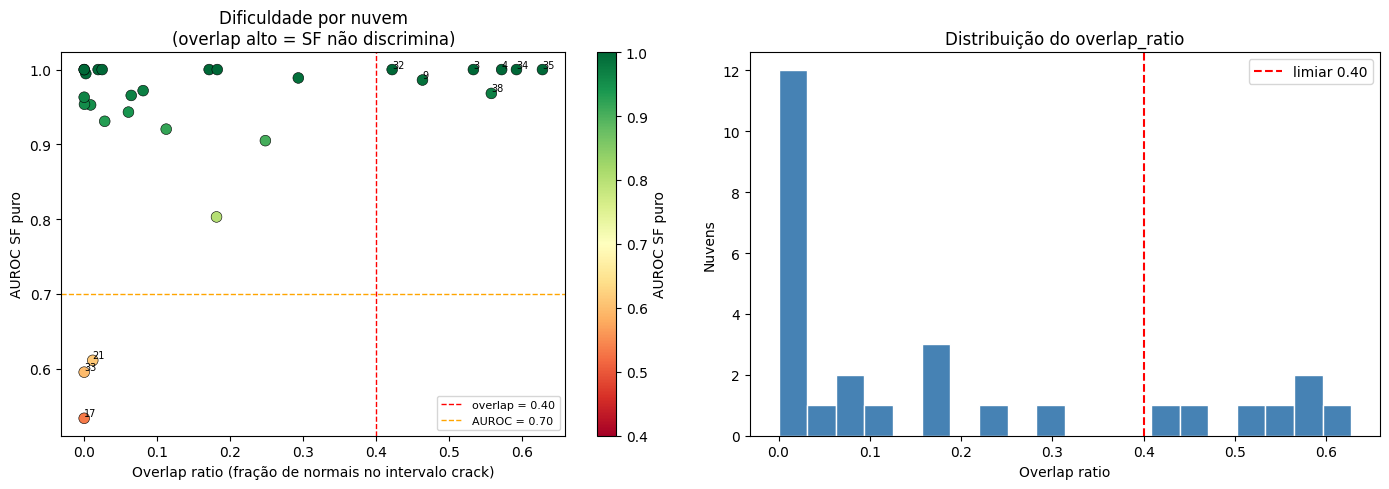

Salvo em visualizations_sf/gmm_interval_analysis.png


In [6]:

# ── Visualização: overlap_ratio vs AUROC por nuvem ───────────────────────────
df_valid = df.dropna(subset=['overlap_ratio', 'auroc_sf'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: overlap_ratio × AUROC_SF
ax = axes[0]
sc = ax.scatter(df_valid['overlap_ratio'], df_valid['auroc_sf'],
                c=df_valid['auroc_sf'], cmap='RdYlGn', vmin=0.4, vmax=1.0,
                s=60, edgecolors='k', linewidths=0.4)
ax.axvline(0.40, color='red', linestyle='--', linewidth=1, label='overlap = 0.40')
ax.axhline(0.70, color='orange', linestyle='--', linewidth=1, label='AUROC = 0.70')

for _, r in df_valid.iterrows():
    if r['auroc_sf'] < 0.75 or r['overlap_ratio'] > 0.30:
        ax.annotate(r['filename'].replace('.ply','').replace('avaria_',''),
                    (r['overlap_ratio'], r['auroc_sf']),
                    fontsize=7, ha='left', va='bottom')

plt.colorbar(sc, ax=ax, label='AUROC SF puro')
ax.set_xlabel('Overlap ratio (fração de normais no intervalo crack)')
ax.set_ylabel('AUROC SF puro')
ax.set_title('Dificuldade por nuvem\n(overlap alto = SF não discrimina)')
ax.legend(fontsize=8)

# Histograma de overlap_ratio
ax = axes[1]
ax.hist(df_valid['overlap_ratio'], bins=20, color='steelblue', edgecolor='white')
ax.axvline(0.40, color='red', linestyle='--', linewidth=1.5, label='limiar 0.40')
ax.set_xlabel('Overlap ratio')
ax.set_ylabel('Nuvens')
ax.set_title('Distribuição do overlap_ratio')
ax.legend()

plt.tight_layout()
plt.savefig('../visualizations_sf/gmm_interval_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvo em visualizations_sf/gmm_interval_analysis.png")


In [8]:

# ════════════════════════════════════════════════════════════════════════════
# ANÁLISE SUPERVISIONADA — correlação de features com scalar_label
# ════════════════════════════════════════════════════════════════════════════
import pandas as pd
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr

FEAT_NAMES = ['x','y','z','r','g','b','nx','ny','nz','sf',
              'curv','dens','var','sv','lum','sat']

# ── 1. Monta DataFrame global com todas as nuvens avaria labeled ─────────────
labeled_clouds = [d for d in all_data if d['has_crack'] and d['labels'] is not None
                  and d['labels'].sum() > 0]

frames = []
for d in labeled_clouds:
    feat = d['features']                        # (N, 16)
    lbl  = d['labels']                          # (N,)  0/1
    df_c = pd.DataFrame(feat, columns=FEAT_NAMES)
    df_c['label']    = lbl
    df_c['cloud_id'] = d['filename']
    frames.append(df_c)

df_all = pd.concat(frames, ignore_index=True)
n_pos  = int(df_all['label'].sum())
n_neg  = int((df_all['label'] == 0).sum())
print(f"Total pontos: {len(df_all):,}  |  crack: {n_pos:,} ({100*n_pos/len(df_all):.1f}%)  |  normal: {n_neg:,}")
print(f"Nuvens: {df_all['cloud_id'].nunique()}")


Total pontos: 476,397  |  crack: 30,826 (6.5%)  |  normal: 445,571
Nuvens: 31


In [9]:

# ── 2. AUROC e Spearman individuais — pooled e por nuvem (mediana) ────────────

def auroc_safe(y_true, y_score):
    """AUROC; retorna nan se apenas uma classe presente."""
    try:
        a = roc_auc_score(y_true, y_score)
        return a if a >= 0.5 else 1 - a   # sempre ≥ 0.5 (inverte se necessário)
    except Exception:
        return float('nan')

rows = []
for feat in FEAT_NAMES:
    # pooled (todos os pontos juntos, sem normalização cross-cloud)
    auroc_pool  = auroc_safe(df_all['label'], df_all[feat])
    spear_pool, _ = spearmanr(df_all[feat], df_all['label'])

    # por nuvem: AUROC em cada nuvem separada → mais justo
    per_cloud = []
    for cid, grp in df_all.groupby('cloud_id'):
        if grp['label'].nunique() < 2:
            continue
        a = auroc_safe(grp['label'], grp[feat])
        per_cloud.append(a)

    auroc_med = float(np.nanmedian(per_cloud))
    auroc_std = float(np.nanstd(per_cloud))
    auroc_min = float(np.nanmin(per_cloud))

    rows.append(dict(feature=feat,
                     auroc_pooled=round(auroc_pool, 4),
                     auroc_per_cloud_med=round(auroc_med, 4),
                     auroc_per_cloud_std=round(auroc_std, 4),
                     auroc_per_cloud_min=round(auroc_min, 4),
                     spearman=round(abs(float(spear_pool)), 4)))

df_feat = pd.DataFrame(rows).sort_values('auroc_per_cloud_med', ascending=False)
print(f"\n{'Feature':<8} {'AUROC pooled':>13} {'per-cloud med':>14} {'per-cloud std':>14} {'per-cloud min':>14} {'|Spearman|':>11}")
print("─" * 78)
for _, r in df_feat.iterrows():
    print(f"{r['feature']:<8} {r['auroc_pooled']:>13.4f} {r['auroc_per_cloud_med']:>14.4f} "
          f"{r['auroc_per_cloud_std']:>14.4f} {r['auroc_per_cloud_min']:>14.4f} {r['spearman']:>11.4f}")



Feature   AUROC pooled  per-cloud med  per-cloud std  per-cloud min  |Spearman|
──────────────────────────────────────────────────────────────────────────────
sf              0.8898         0.9888         0.1236         0.5335      0.3322
y               0.5019         0.5087         0.0087         0.5003      0.0016
var             0.5114         0.5087         0.0139         0.5003      0.0098
curv            0.5078         0.5086         0.0085         0.5010      0.0067
dens            0.5119         0.5084         0.0154         0.5002      0.0102
sat             0.5443         0.5084         0.0109         0.5003      0.0378
lum             0.5800         0.5082         0.0069         0.5003      0.0682
x               0.5085         0.5075         0.0100         0.5001      0.0072
r               0.5467         0.5075         0.0087         0.5001      0.0398
ny              0.5414         0.5074         0.0065         0.5004      0.0353
b               0.5814         0.5073   

In [10]:

# ── 3. Partial correlation: o que cada feature acrescenta ALÉM do SF? ─────────
# Método: resíduo de regressão linear de cada feature em sf → correlação
#         desse resíduo com label. Sinal residual ≠ 0 → feature independente de SF.
from scipy.stats import spearmanr
from numpy.polynomial import polynomial as P

rows_partial = []
sf_vals = df_all['sf'].values
lbl_vals = df_all['label'].values

# Resíduo de sf vs label (controle)
coef = np.polyfit(sf_vals, lbl_vals, 1)
sf_resid_label = lbl_vals - np.polyval(coef, sf_vals)

for feat in FEAT_NAMES:
    if feat == 'sf':
        rows_partial.append(dict(feature='sf', partial_spearman=float('nan'),
                                 auroc_partial=float('nan')))
        continue

    feat_vals = df_all[feat].values

    # Regride feat em sf e pega resíduo
    try:
        c = np.polyfit(sf_vals, feat_vals, 1)
        feat_resid = feat_vals - np.polyval(c, sf_vals)
    except Exception:
        feat_resid = feat_vals

    # Correlação do resíduo com label
    sp, _ = spearmanr(feat_resid, lbl_vals)

    # AUROC do resíduo vs label
    try:
        a = roc_auc_score(lbl_vals, feat_resid)
        a = a if a >= 0.5 else 1 - a
    except Exception:
        a = float('nan')

    rows_partial.append(dict(feature=feat,
                             partial_spearman=round(abs(float(sp)), 4),
                             auroc_partial=round(float(a), 4)))

df_partial = pd.DataFrame(rows_partial).sort_values('auroc_partial', ascending=False)

print(f"\n{'Feature':<8} {'|Partial Spearman|':>20} {'AUROC (resíduo)':>16}")
print("─" * 48)
for _, r in df_partial.iterrows():
    sp_str = f"{r['partial_spearman']:.4f}" if not np.isnan(r['partial_spearman']) else "   ref"
    au_str = f"{r['auroc_partial']:.4f}"    if not np.isnan(r['auroc_partial'])    else "   ref"
    print(f"{r['feature']:<8} {sp_str:>20} {au_str:>16}")

print("\nInterpretação: AUROC (resíduo) > 0.55 → feature contém sinal além do SF")



Feature    |Partial Spearman|  AUROC (resíduo)
────────────────────────────────────────────────
sv                     0.1599           0.6876
sat                    0.0974           0.6143
nx                     0.0827           0.5970
r                      0.0787           0.5923
lum                    0.0593           0.5696
ny                     0.0476           0.5559
b                      0.0458           0.5537
curv                   0.0430           0.5504
var                    0.0300           0.5352
nz                     0.0277           0.5325
g                      0.0101           0.5119
dens                   0.0095           0.5111
x                      0.0088           0.5104
y                      0.0084           0.5098
z                      0.0002           0.5002
sf                        ref              ref

Interpretação: AUROC (resíduo) > 0.55 → feature contém sinal além do SF


In [12]:
# ── 4. AUROC de combinações de features ───────────────────────────────────────
eps = 1e-8

combinations = {
    'sf*lum'      : df_all['sf'] * df_all['lum'],
    'sf*sat'      : df_all['sf'] * df_all['sat'],
    'sf*(1-curv)' : df_all['sf'] * (1 - df_all['curv']),
    'sf/dens'     : df_all['sf'] / (df_all['dens'] + eps),
    'sf*lum*sat'  : df_all['sf'] * df_all['lum'] * df_all['sat'],
    '(sf+lum)/2'  : (df_all['sf'] + df_all['lum']) / 2,
    'lum*sat'     : df_all['lum'] * df_all['sat'],
    'r*g*b'       : df_all['r'] * df_all['g'] * df_all['b'],
    'sf-lum'      : df_all['sf'] - df_all['lum'],
    'sf/lum'      : df_all['sf'] / (df_all['lum'] + eps),
    'curv/sf'     : df_all['curv'] / (df_all['sf'] + eps),
    'sf*|nz|'     : df_all['sf'] * df_all['nz'].abs(),
}

sf_auroc_pool = auroc_safe(df_all['label'].values, df_all['sf'].values)

comb_rows = []
for name, combo in combinations.items():
    combo_arr = combo.values

    a_pool = auroc_safe(df_all['label'].values, combo_arr)

    per_cloud_a = []
    for cid, grp in df_all.groupby('cloud_id'):
        if grp['label'].nunique() < 2:
            continue
        a = auroc_safe(grp['label'].values, combo_arr[grp.index])
        per_cloud_a.append(a)

    comb_rows.append(dict(
        combo=name,
        auroc_pooled=round(a_pool, 4),
        auroc_per_cloud_med=round(float(np.nanmedian(per_cloud_a)), 4),
        delta_vs_sf=round(a_pool - sf_auroc_pool, 4),
    ))

df_comb = pd.DataFrame(comb_rows).sort_values('auroc_per_cloud_med', ascending=False)

print(f"\n{'Combinação':<16} {'AUROC pooled':>13} {'per-cloud med':>14} {'Δ vs SF':>10}")
print("─" * 58)
print(f"{'sf (baseline)':<16} {sf_auroc_pool:>13.4f} {'—':>14} {'0.0000':>10}")
for _, r in df_comb.iterrows():
    flag = ' ▲' if r['delta_vs_sf'] > 0.001 else ''
    print(f"{r['combo']:<16} {r['auroc_pooled']:>13.4f} {r['auroc_per_cloud_med']:>14.4f} "
          f"{r['delta_vs_sf']:>+10.4f}{flag}")



Combinação        AUROC pooled  per-cloud med    Δ vs SF
──────────────────────────────────────────────────────────
sf (baseline)           0.8898              —     0.0000
sf-lum                  0.8618         0.9630    -0.0281
sf*(1-curv)             0.8674         0.9624    -0.0224
(sf+lum)/2              0.8740         0.9609    -0.0158
sf/lum                  0.8440         0.9428    -0.0459
sf*lum                  0.8609         0.9408    -0.0290
sf/dens                 0.8426         0.9369    -0.0472
sf*lum*sat              0.6906         0.7936    -0.1992
sf*sat                  0.6852         0.7916    -0.2046
curv/sf                 0.7117         0.7811    -0.1781
sf*|nz|                 0.5872         0.6965    -0.3027
r*g*b                   0.5830         0.5084    -0.3068
lum*sat                 0.5206         0.5066    -0.3693


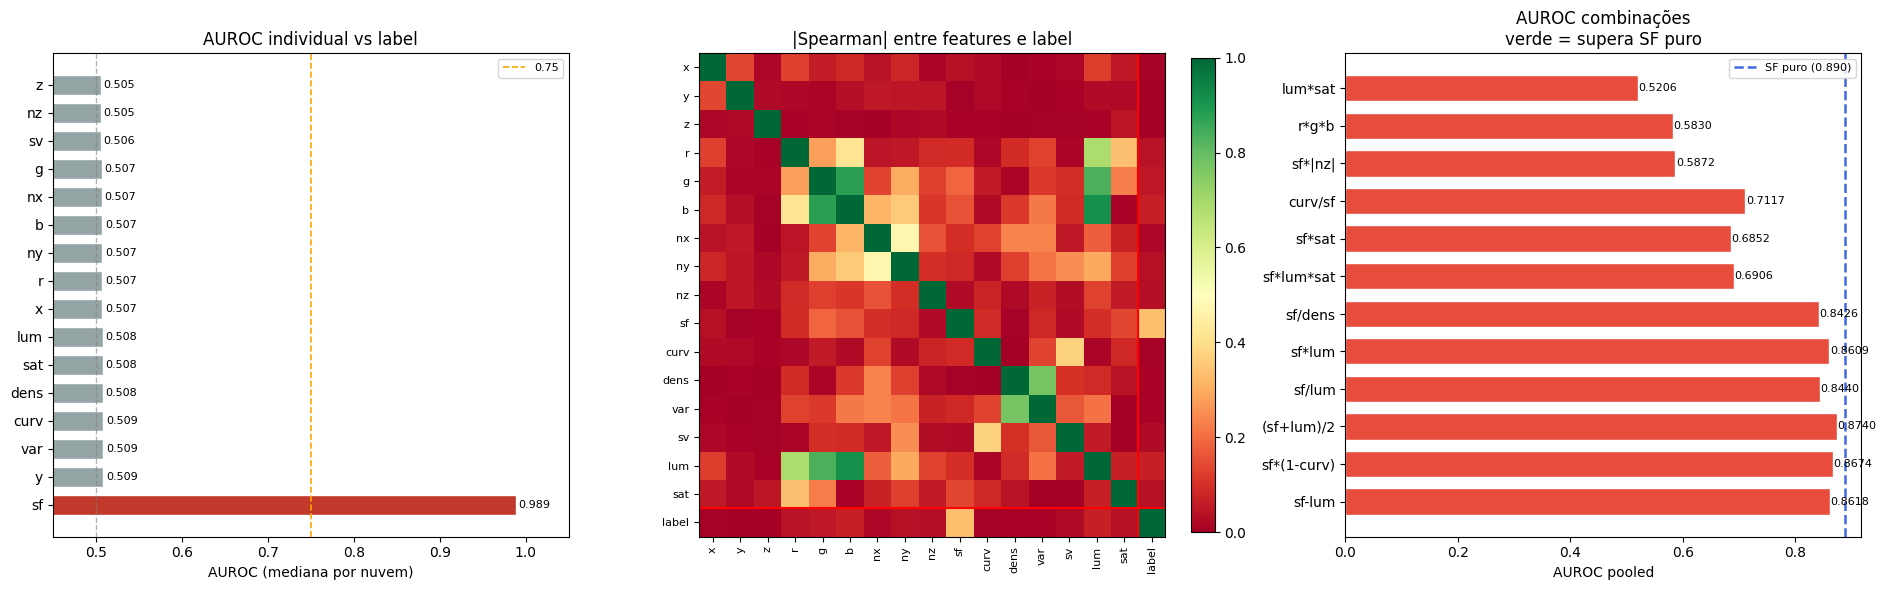

Salvo em visualizations_sf/supervised_feature_analysis.png


In [13]:
# ── 5. Visualização: AUROC individual + heatmap + combinações ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

# ─ 5a. Bar chart: AUROC per-cloud por feature ────────────────────────────────
ax = axes[0]
df_plot = df_feat.set_index('feature')
colors = ['#c0392b' if v > 0.80 else '#e67e22' if v > 0.60 else '#95a5a6'
          for v in df_plot['auroc_per_cloud_med']]
bars = ax.barh(df_plot.index, df_plot['auroc_per_cloud_med'],
               color=colors, edgecolor='white', height=0.7)
ax.axvline(0.5,  color='gray',   linestyle='--', linewidth=1, alpha=0.6)
ax.axvline(0.75, color='orange', linestyle='--', linewidth=1.2, label='0.75')
for bar, val in zip(bars, df_plot['auroc_per_cloud_med']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
ax.set_xlim(0.45, 1.05)
ax.set_xlabel('AUROC (mediana por nuvem)')
ax.set_title('AUROC individual vs label')
ax.legend(fontsize=8)

# ─ 5b. Heatmap |Spearman|: features × features (+ label) ─────────────────────
ax = axes[1]
cols_hm = FEAT_NAMES + ['label']
corr_mat = np.zeros((len(cols_hm), len(cols_hm)))
for i, f1 in enumerate(cols_hm):
    for j, f2 in enumerate(cols_hm):
        sp, _ = spearmanr(df_all[f1], df_all[f2])
        corr_mat[i, j] = abs(float(sp))

im = ax.imshow(corr_mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_xticks(range(len(cols_hm))); ax.set_xticklabels(cols_hm, rotation=90, fontsize=8)
ax.set_yticks(range(len(cols_hm))); ax.set_yticklabels(cols_hm, fontsize=8)
ax.set_title('|Spearman| entre features e label')
n = len(FEAT_NAMES)
ax.axhline(n - 0.5, color='red', linewidth=1.5)
ax.axvline(n - 0.5, color='red', linewidth=1.5)

# ─ 5c. Bar chart: AUROC das combinações vs baseline ──────────────────────────
ax = axes[2]
df_c_plot = df_comb.set_index('combo')
colors_c = ['#27ae60' if v > sf_auroc_pool else '#e74c3c'
            for v in df_c_plot['auroc_pooled']]
bars = ax.barh(df_c_plot.index, df_c_plot['auroc_pooled'],
               color=colors_c, edgecolor='white', height=0.7)
ax.axvline(sf_auroc_pool, color='royalblue', linestyle='--', linewidth=1.8,
           label=f'SF puro ({sf_auroc_pool:.3f})')
for bar, val in zip(bars, df_c_plot['auroc_pooled']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
ax.set_xlabel('AUROC pooled')
ax.set_title('AUROC combinações\nverde = supera SF puro')
ax.legend(fontsize=8)

plt.tight_layout()
os.makedirs('../visualizations_sf', exist_ok=True)
plt.savefig('../visualizations_sf/supervised_feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvo em visualizations_sf/supervised_feature_analysis.png")


In [14]:

# ════════════════════════════════════════════════════════════════════════════
# COMPARAÇÃO pred vs scalar_labels — teacher_student_v1
# Métricas com tratamento de desbalanceamento (93.4% normal / 6.6% crack)
# ════════════════════════════════════════════════════════════════════════════
import glob, os
from plyfile import PlyData
from sklearn.metrics import (
    confusion_matrix, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    balanced_accuracy_score, classification_report
)

# ── 1. Carrega predições (PLY) e ground truth ─────────────────────────────
gt_map = {d['filename']: d['labels']
          for d in all_data
          if d.get('has_crack') and d['labels'] is not None and d['labels'].sum() > 0}

ply_files = sorted(glob.glob('../results_ts/ply/*.ply'))

rows = []
all_pred, all_gt = [], []

for pf in ply_files:
    fname = os.path.basename(pf).replace('_pred_v2.ply', '.ply')
    if fname not in gt_map:
        continue

    v      = PlyData.read(pf)['vertex']
    pred   = ((np.array(v['red']) > 200) &
               (np.array(v['green']) < 80) &
               (np.array(v['blue'])  < 80)).astype(int)
    labels = gt_map[fname]

    if len(pred) != len(labels):
        continue

    # métricas por nuvem
    n_crack  = int(labels.sum())
    n_normal = int((labels == 0).sum())

    p   = precision_score(labels, pred, zero_division=0)
    r   = recall_score(labels, pred, zero_division=0)
    f1  = f1_score(labels, pred, zero_division=0)
    mcc = matthews_corrcoef(labels, pred)
    bal = balanced_accuracy_score(labels, pred)
    tn, fp, fn, tp = confusion_matrix(labels, pred, labels=[0,1]).ravel()

    rows.append(dict(
        arquivo   = fname,
        n_crack   = n_crack,
        n_normal  = n_normal,
        imbalance = round(n_crack / (n_crack + n_normal), 4),
        TP=int(tp), FP=int(fp), FN=int(fn), TN=int(tn),
        precisao  = round(float(p),   4),
        recall    = round(float(r),   4),
        f1        = round(float(f1),  4),
        mcc       = round(float(mcc), 4),
        bal_acc   = round(float(bal), 4),
    ))

    all_pred.extend(pred.tolist())
    all_gt.extend(labels.tolist())

df_cmp = pd.DataFrame(rows).sort_values('f1')
all_pred = np.array(all_pred)
all_gt   = np.array(all_gt)

print(f"Nuvens avaliadas: {len(rows)}")
print(f"Total pontos — crack: {all_gt.sum():,}  normal: {(all_gt==0).sum():,}  "
      f"({100*all_gt.mean():.1f}% crack)")


Nuvens avaliadas: 31
Total pontos — crack: 30,826  normal: 445,571  (6.5% crack)


In [15]:

# ── 2. Tabela por nuvem ───────────────────────────────────────────────────
print(f"{'Arquivo':<35} {'%crack':>7} {'TP':>6} {'FP':>6} {'FN':>6} "
      f"{'P':>6} {'R':>6} {'F1':>6} {'MCC':>6} {'BalAcc':>7}")
print("─" * 100)

for _, row in df_cmp.iterrows():
    flag = ' ◄' if row['f1'] < 0.70 else ''
    print(f"{row['arquivo']:<35} {row['imbalance']*100:>6.1f}%"
          f" {row['TP']:>6,} {row['FP']:>6,} {row['FN']:>6,}"
          f" {row['precisao']:>6.3f} {row['recall']:>6.3f}"
          f" {row['f1']:>6.3f} {row['mcc']:>6.3f} {row['bal_acc']:>7.3f}{flag}")

print("\n" + "─" * 100)
print("Por que MCC e Balanced Accuracy:")
print("  • F1 ignora os True Negatives — faz sentido para crack (minoria)")
print("    mas não penaliza modelos que erram muito nos normais.")
print("  • MCC leva em conta TP, TN, FP, FN igualmente — robusto ao desbalanceamento.")
print("    Range [-1, 1]: 0 = aleatório, 1 = perfeito.")
print("  • Balanced Accuracy = (Recall_crack + Specificity) / 2")
print("    Specificity = TN / (TN+FP) — quão bem o modelo acerta os NORMAIS.")


Arquivo                              %crack     TP     FP     FN      P      R     F1    MCC  BalAcc
────────────────────────────────────────────────────────────────────────────────────────────────────
avaria_21.ply                          6.1%      2      7     92  0.222  0.021  0.039  0.052   0.508 ◄
avaria_40.ply                          6.9%    627    572      0  0.523  1.000  0.687  0.698   0.966 ◄
avaria_26.ply                          6.8%    573    227    163  0.716  0.778  0.746  0.728   0.878
avaria_17.ply                          4.2%    754    177    266  0.810  0.739  0.773  0.764   0.866
avaria_36.ply                          8.2%  1,217    581     34  0.677  0.973  0.798  0.792   0.966
avaria_41.ply                         23.0%  2,569      0  1,196  1.000  0.682  0.811  0.789   0.841
avaria_33.ply                          7.3%  1,217     45    506  0.964  0.706  0.815  0.814   0.852
avaria_39.ply                          2.2%    395    170      0  0.699  1.000  0.823  

In [16]:

# ── 3. Métricas globais (todos os pontos de todas as nuvens) ─────────────
print("=" * 60)
print("MÉTRICAS GLOBAIS — teacher_student_v1 (todos os pontos)")
print("=" * 60)

# Classe desbalanceada: 6.62% crack
print(f"\nDesbalanceamento: {100*all_gt.mean():.2f}% crack  |  "
      f"{100*(1-all_gt.mean()):.2f}% normal\n")

# Confusion matrix global
cm = confusion_matrix(all_gt, all_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
total = len(all_gt)

print(f"  Confusion Matrix (global):")
print(f"                 Pred Normal  Pred Crack")
print(f"  Real Normal  : {tn:>11,}  {fp:>10,}   (Specificity={tn/(tn+fp):.4f})")
print(f"  Real Crack   : {fn:>11,}  {tp:>10,}   (Recall={tp/(tp+fn):.4f})")
print()

# Métricas com peso por classe
metrics = {
    'Precision (crack)'       : precision_score(all_gt, all_pred, zero_division=0),
    'Recall (crack)'          : recall_score(all_gt, all_pred, zero_division=0),
    'F1 (crack)'              : f1_score(all_gt, all_pred, zero_division=0),
    'F1 macro (crack+normal)' : f1_score(all_gt, all_pred, average='macro', zero_division=0),
    'F1 weighted'             : f1_score(all_gt, all_pred, average='weighted', zero_division=0),
    'MCC'                     : matthews_corrcoef(all_gt, all_pred),
    'Balanced Accuracy'       : balanced_accuracy_score(all_gt, all_pred),
    'Specificity (normais)'   : tn / (tn + fp) if (tn + fp) > 0 else 0,
}

for name, val in metrics.items():
    bar = '█' * int(abs(val) * 25)
    print(f"  {name:<30} {val:>7.4f}  {bar}")

print()
print("  Interpretation:")
print(f"  • MCC={metrics['MCC']:.4f} {'(bom)' if metrics['MCC'] > 0.7 else '(moderado)' if metrics['MCC'] > 0.4 else '(fraco)'}")
print(f"  • Specificity={metrics['Specificity (normais)']:.4f} → "
      f"{'poucos FP nos normais' if metrics['Specificity (normais)'] > 0.99 else 'FPs nos normais presentes'}")
print(f"  • Balanced Acc={metrics['Balanced Accuracy']:.4f} → "
      f"{'boa' if metrics['Balanced Accuracy'] > 0.85 else 'moderada'} performance em ambas as classes")


MÉTRICAS GLOBAIS — teacher_student_v1 (todos os pontos)

Desbalanceamento: 6.47% crack  |  93.53% normal

  Confusion Matrix (global):
                 Pred Normal  Pred Crack
  Real Normal  :     443,177       2,394   (Specificity=0.9946)
  Real Crack   :       2,520      28,306   (Recall=0.9183)

  Precision (crack)               0.9220  ███████████████████████
  Recall (crack)                  0.9183  ██████████████████████
  F1 (crack)                      0.9201  ███████████████████████
  F1 macro (crack+normal)         0.9573  ███████████████████████
  F1 weighted                     0.9897  ████████████████████████
  MCC                             0.9146  ██████████████████████
  Balanced Accuracy               0.9564  ███████████████████████
  Specificity (normais)           0.9946  ████████████████████████

  Interpretation:
  • MCC=0.9146 (bom)
  • Specificity=0.9946 → poucos FP nos normais
  • Balanced Acc=0.9564 → boa performance em ambas as classes


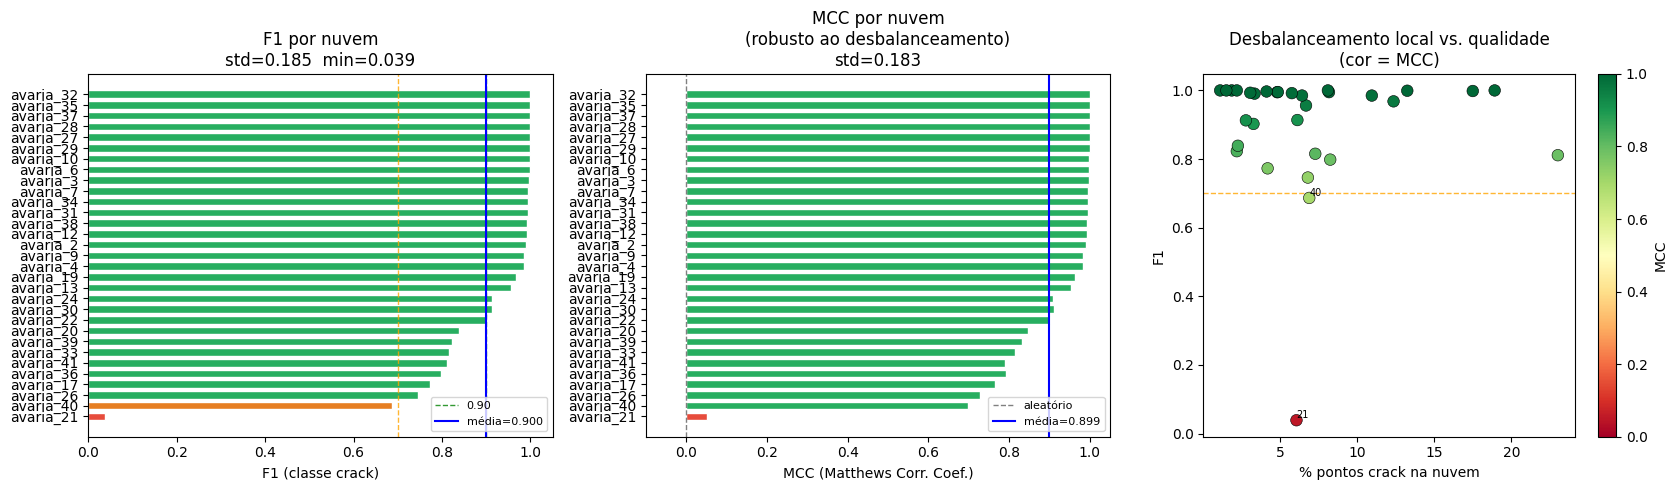

Salvo em visualizations_sf/pred_vs_labels_analysis.png


In [17]:

# ── 4. Visualização: distribuição de F1, MCC e BalAcc por nuvem ──────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ─ 4a. F1 por nuvem (ordenado) ───────────────────────────────────────────
ax = axes[0]
colors = ['#e74c3c' if v < 0.50 else '#e67e22' if v < 0.70 else '#27ae60'
          for v in df_cmp['f1']]
bars = ax.barh(df_cmp['arquivo'].str.replace('.ply',''), df_cmp['f1'],
               color=colors, edgecolor='white', height=0.7)
ax.axvline(0.7,  color='orange', linestyle='--', linewidth=1, alpha=0.8)
ax.axvline(0.9,  color='green',  linestyle='--', linewidth=1, alpha=0.8, label='0.90')
ax.axvline(df_cmp['f1'].mean(), color='blue', linestyle='-',
           linewidth=1.5, label=f"média={df_cmp['f1'].mean():.3f}")
ax.set_xlabel('F1 (classe crack)')
ax.set_title(f"F1 por nuvem\nstd={df_cmp['f1'].std():.3f}  min={df_cmp['f1'].min():.3f}")
ax.set_xlim(0, 1.05)
ax.legend(fontsize=8)

# ─ 4b. MCC por nuvem ─────────────────────────────────────────────────────
ax = axes[1]
colors_m = ['#e74c3c' if v < 0.3 else '#e67e22' if v < 0.6 else '#27ae60'
            for v in df_cmp['mcc']]
ax.barh(df_cmp['arquivo'].str.replace('.ply',''), df_cmp['mcc'],
        color=colors_m, edgecolor='white', height=0.7)
ax.axvline(0, color='gray', linestyle='--', linewidth=1, label='aleatório')
ax.axvline(df_cmp['mcc'].mean(), color='blue', linestyle='-',
           linewidth=1.5, label=f"média={df_cmp['mcc'].mean():.3f}")
ax.set_xlabel('MCC (Matthews Corr. Coef.)')
ax.set_title(f"MCC por nuvem\n(robusto ao desbalanceamento)\nstd={df_cmp['mcc'].std():.3f}")
ax.set_xlim(-0.1, 1.05)
ax.legend(fontsize=8)

# ─ 4c. Scatter: %crack vs F1 (impacto do desbalanceamento por nuvem) ─────
ax = axes[2]
sc = ax.scatter(df_cmp['imbalance']*100, df_cmp['f1'],
                c=df_cmp['mcc'], cmap='RdYlGn', vmin=0, vmax=1,
                s=70, edgecolors='k', linewidths=0.4, zorder=3)
for _, row in df_cmp[df_cmp['f1'] < 0.70].iterrows():
    ax.annotate(row['arquivo'].replace('.ply','').replace('avaria_',''),
                (row['imbalance']*100, row['f1']),
                fontsize=7, ha='left', va='bottom')
plt.colorbar(sc, ax=ax, label='MCC')
ax.axhline(0.7, color='orange', linestyle='--', linewidth=1, alpha=0.8)
ax.set_xlabel('% pontos crack na nuvem')
ax.set_ylabel('F1')
ax.set_title('Desbalanceamento local vs. qualidade\n(cor = MCC)')

plt.tight_layout()
os.makedirs('../visualizations_sf', exist_ok=True)
plt.savefig('../visualizations_sf/pred_vs_labels_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvo em visualizations_sf/pred_vs_labels_analysis.png")
